# Transition Temperatures

`plot_phase_diagram(..., transition_temperatures=True)` labels every invariant of a refined phase diagram with its temperature.
Two kinds of point are tagged in the `locus` column of the `calc_phase_diagram` frame:

* `triple`: three phases coexist on an isotherm (eutectic, peritectic, eutectoid, peritectoid, monotectic),
* `congruent`: two coexisting phases share a composition (congruent melting point, congruent minimum or maximum of a lens, azeotrope, the melting point of a pure component).

This notebook builds the textbook binary systems, one per reaction, from `LinePhase`, `IdealSolution` and `FastInterpolatingPhase`.

## Prelude

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from landau.phases import LinePhase, IdealSolution, FastInterpolatingPhase, kB
from landau.interpolate import PolyFit
from landau.calculate import calc_phase_diagram
from landau.plot import plot_phase_diagram, plot_mu_phase_diagram

Energies are in eV/atom, entropies in units of $k_B$.
A line phase has $f(T) = E - T S$, so a pure component melts at $T_m = \Delta E / \Delta S$.

In [2]:
def line(name, c, E, S):
    return LinePhase(name, fixed_concentration=c, line_energy=E, line_entropy=S * kB)

def ideal(name, E_A, S_A, E_B, S_B):
    """Ideal solution between the terminals A (c=0) and B (c=1)."""
    return IdealSolution(name, line(name + "A", 0, E_A, S_A), line(name + "B", 1, E_B, S_B))

def regular(name, E_A, S_A, E_B, S_B, L0, L1=0):
    """Sub-regular solution with mixing enthalpy c (1 - c) (L0 + L1 (2c - 1)); L0 < 0 attracts, L0 > 0 repels."""
    E_mix = lambda c: c * (1 - c) * (L0 + L1 * (2 * c - 1))
    controls = [
        line(f"{name}{i}", c, (1 - c) * E_A + c * E_B + E_mix(c), (1 - c) * S_A + c * S_B)
        for i, c in enumerate([0, 0.25, 0.5, 0.75, 1])
    ]
    return FastInterpolatingPhase(name, phases=controls, add_entropy=True, interpolator=PolyFit(4))

alpha = line("α", 0, -3.0, 1.0)
beta = line("β", 1, -2.5, 1.0)
liquid = ideal("liquid", -2.8, 3.0, -2.35, 3.0)
Ts = np.linspace(300, 1500, 60)

def diagram(phases, Ts=Ts, ax=None, **kwargs):
    df = calc_phase_diagram(phases, Ts, mu=100)
    plot_phase_diagram(df, transition_temperatures=True, ax=ax, **kwargs)
    return df

## Congruent minimum: the ethanol-water azeotrope

A minimum-boiling azeotrope is the vapour-liquid version of a congruent minimum.
Water and ethanol boil at 373.15 K and 351.4 K, the azeotrope at 351.3 K and 89.4 mol% ethanol.
Entropies of vaporisation come from the real enthalpies; the two liquid interaction parameters are solved so that the liquid and vapour free energies touch with a common slope exactly at the azeotrope.
The azeotrope sits only 0.1 K below the boiling point of ethanol, so the lens is nearly flat from 80 mol% on; both are tagged.

In [3]:
T_w, T_e = 373.15, 351.4
S_w, S_e = 40.65e3 / T_w / 8.314, 38.6e3 / T_e / 8.314   # kB units
c_az, T_az = 0.894, 351.3

# vapour - liquid at the azeotrope temperature, without mixing: E_mix must match it in value and slope at c_az
g = lambda c: (1 - c) * S_w * kB * (T_w - T_az) + c * S_e * kB * (T_e - T_az)
c = c_az
M = np.array([[c * (1 - c), c * (1 - c) * (2 * c - 1)],
              [1 - 2 * c, (1 - 2 * c) * (2 * c - 1) + 2 * c * (1 - c)]])
L0, L1 = np.linalg.solve(M, [g(c), g(1) - g(0)])

ethanol_water = regular("liquid", 0, 0, 0, 0, L0, L1)
vapour = ideal("vapour", S_w * kB * T_w, S_w, S_e * kB * T_e, S_e)

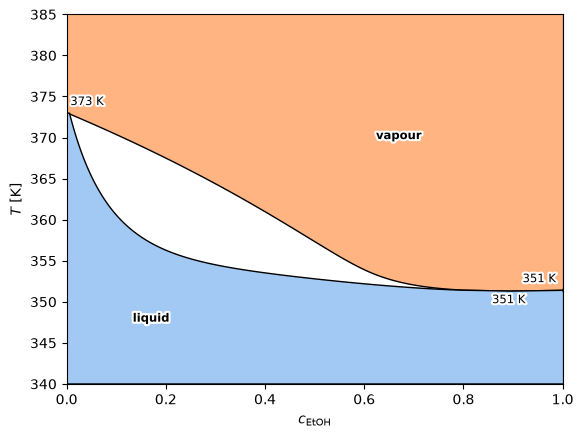

In [4]:
df = diagram([ethanol_water, vapour], Ts=np.linspace(340, 385, 90), element="EtOH")

In [5]:
df.query("locus == 'congruent'")[["T", "c", "phase", "locus"]]

,T,c,phase,locus
18180,351.392229,0.995164,vapour,congruent
18181,351.392229,0.995451,liquid,congruent
18414,372.962581,0.007346,vapour,congruent
18415,372.962581,0.000790,liquid,congruent
18416,351.299991,0.893996,vapour,congruent
18417,351.299991,0.893996,liquid,congruent


## Eutectic

$L \rightarrow \alpha + \beta$.
Two line phases with no mutual solubility and an ideal liquid.
The three-phase isotherm is drawn as a line, its temperature labelled in the two-phase field above it.
In the $\mu$-$T$ diagram the three phases meet in a point.

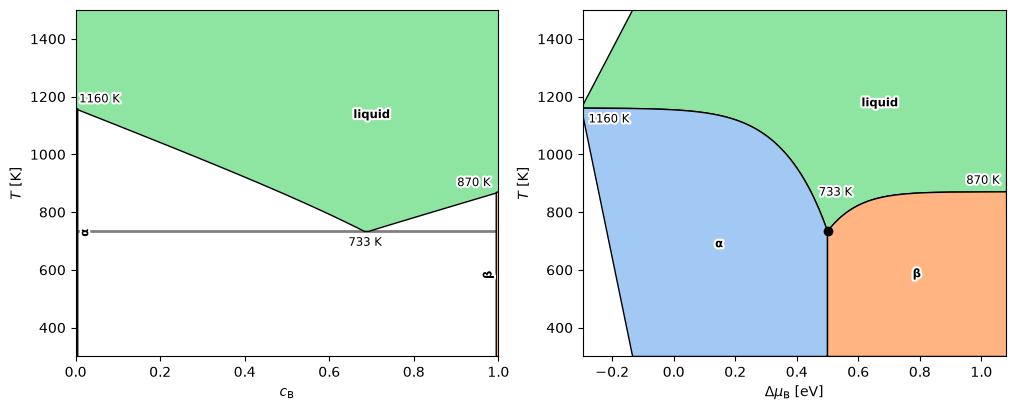

In [6]:
fig, (ax_c, ax_mu) = plt.subplots(1, 2, figsize=(12, 4.5))
df = diagram([alpha, beta, liquid], ax=ax_c, element="B")
plot_mu_phase_diagram(df, element="B", transition_temperatures=True, ax=ax_mu)

In [7]:
df.query("locus == 'triple'")[["T", "c", "phase", "locus"]]

,T,c,phase,locus
18120,733.282818,0.000000,α,triple
18121,733.282818,1.000000,β,triple
18122,733.282818,0.688104,liquid,triple


## Peritectic

$L + \\alpha \\rightarrow \\beta$.
Two terminal solid solutions, A melting much higher than B.
Both solid-liquid lenses descend towards B, so the liquidus is monotone and the $\\beta$ field is capped by the peritectic isotherm above the melting point of B, where $\\beta$ forms from $\\alpha$ and a liquid richer in B than itself.
Solubilities are exaggerated.

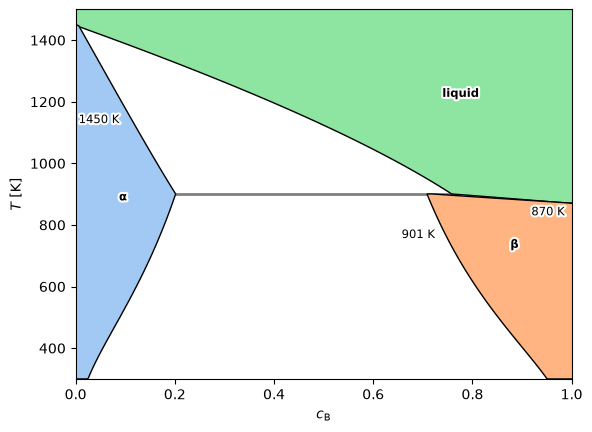

In [8]:
liquid_hot = ideal("liquid", -2.75, 3.0, -2.35, 3.0)
alpha_ss = ideal("α", -3.0, 1.0, -2.40, 1.0)
beta_ss = ideal("β", -2.92, 1.0, -2.5, 1.0)
df = diagram([alpha_ss, beta_ss, liquid_hot], element="B")

## Congruently melting compound

A more stable $\gamma$ melts directly into a liquid of its own composition; a congruent maximum in the liquidus, with a eutectic on either side.

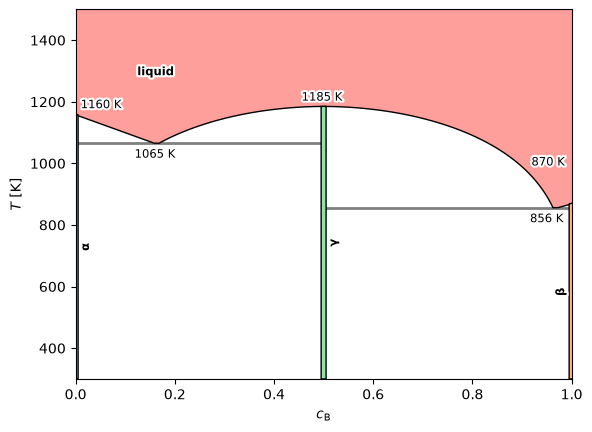

In [9]:
gamma = line("γ", 0.5, -2.85, 1.0)
df = diagram([alpha, beta, gamma, liquid], element="B")

## Eutectoid

$\gamma \rightarrow \alpha + \beta$.
The eutectic geometry with the liquid replaced by a solid solution $\gamma$; the liquid on top melts $\gamma$ through an isomorphous lens.
The allotropic transitions of the pure components, $\alpha \leftrightarrow \gamma$ and $\beta \leftrightarrow \gamma$, are congruent points too.

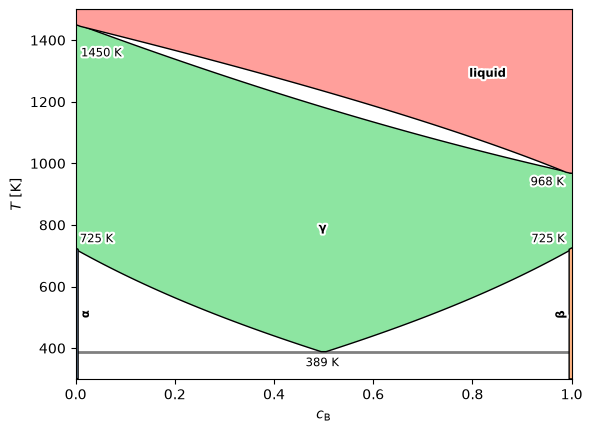

In [10]:
gamma = ideal("γ", -2.95, 1.8, -2.45, 1.8)
df = diagram([alpha, beta, gamma, liquid], element="B")

## Peritectoid

$\alpha + \beta \rightarrow \gamma$.
A low-entropy compound that is only stable at low temperature; on heating it decomposes into the two solids, well below the eutectic.

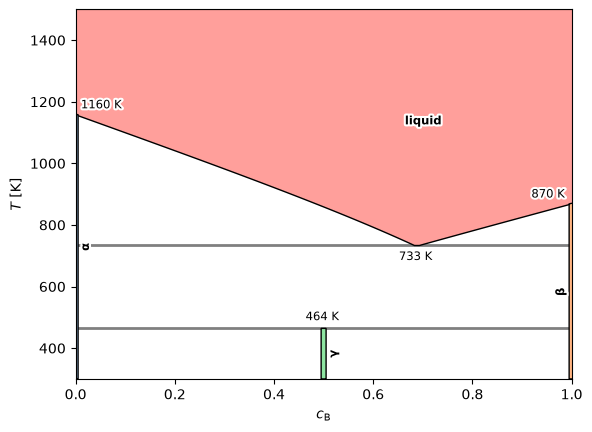

In [11]:
gamma = line("γ", 0.5, -2.77, 0.5)
df = diagram([alpha, beta, gamma, liquid], element="B")

In [12]:
df.query("locus in ['triple', 'congruent']").groupby(["T", "locus"]).phase.agg(list)

T            locus    
464.180753   triple            [β, α, γ]
733.282806   triple       [β, liquid, α]
870.265486   congruent       [β, liquid]
1159.924122  congruent       [α, liquid]
Name: phase, dtype: object

## Monotectic

$L_1 \\rightarrow \\alpha + L_2$.
A repulsive liquid separates into two liquids below its critical point, and the miscibility gap runs into the $\\alpha$ liquidus.
One phase takes part twice here, so the invariant is found by the miscibility-gap tracer rather than from a three-phase simplex; the two liquid rows carry the two branch compositions.

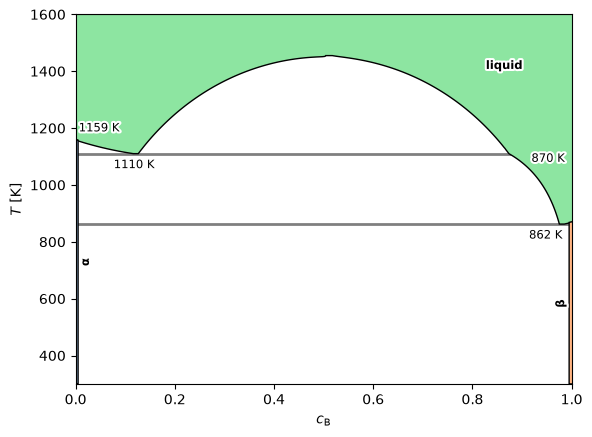

In [13]:
liquid_repulsive = regular("liquid", -2.8, 3.0, -2.35, 3.0, L0=0.25)
df = diagram([alpha, beta, liquid_repulsive], Ts=np.linspace(300, 1600, 80), element="B")

In [14]:
df.query("locus == 'triple'")[["T", "c", "phase", "refined"]]

,T,c,phase,refined
24160,862.301908,1.000000,β,delaunay-triple
24161,862.301908,0.980244,liquid,delaunay-triple
24162,862.301908,0.000000,α,delaunay-triple
25023,1109.997544,0.121300,liquid,miscibility-gap
25024,1109.997544,0.878620,liquid,miscibility-gap
25025,1109.997544,0.000000,α,miscibility-gap


## Notes

* The labels only read the `locus` tags back, so an unrefined diagram (`refine=False`) draws none.
* `transition_temperatures=True` also draws the three-phase isotherms; pass `triplepoints=False` to keep only the labels.